На базе баскетбольных матчей добейтесь средней абсолютной ошибки 17 и менее очков.

### Подготовка  

In [ ]:
# Загрузка из google облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv', None, quiet=True)

# Библиотека для работы с базами
import pandas as pd
df = pd.read_csv('basketball.csv', encoding= 'cp1251', sep=';', header=0, index_col=0) # Загружаем базу
df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


Извлекаем текстовые данные из колонки `info` таблицы, помещаем в переменную `data_text`. Выводим длину списка:

In [ ]:
data_text = df['info'].values #

len(data_text)

52450

Задаем максимальное кол-во слов в словаре, помещаем в переменную все символы, которые хотим вычистить из текста.

 Токенизируем текстовые данные:

In [ ]:
# Импортируем токенайзер
from tensorflow.keras.preprocessing.text import Tokenizer

maxWordsCount = 5000

sim_for_del='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer (num_words=maxWordsCount,
                       filters=sim_for_del,
                       lower=True,
                       split=' ',
                       oov_token='unknown',
                       char_level=False)

tokenizer.fit_on_texts(data_text)

In [ ]:
# Переводим в Эмбеддинг пространство
Sequences = tokenizer.texts_to_sequences(data_text)

# Вариант  Bag of Words
xBOW_text = tokenizer.sequences_to_matrix(Sequences)

Преобразуем данные в numpy, подготовим наборы для обучения:

In [ ]:
# Библиотека работы с массивами
import numpy as np

xTrain = np.array(df[['Ком. 1','Ком. 2', 'Минута', 'Секунда','ftime']].astype('int'))
yTrain = np.array(df['fcount'].astype('int'))

In [ ]:
print(xTrain.shape)
print(yTrain.shape)
print(xBOW_text.shape)

(52450, 5)
(52450,)
(52450, 5000)


In [ ]:
# Функция по проверке ошибки

def check_MAE_predictl_DubbleInput (model,
                                    x_data,
                                    x_data_text,
                                    y_data_not_scaled,
                                    plot=False):

  mae = 0 # Инициализируем начальное значение ошибки
  y_pred = (model.predict([x_data,x_data_text])).squeeze()

  for n in range (0,len(x_data)):
    mae += abs(y_data_not_scaled[n] - y_pred[n]) # Увеличиваем значение ошибки для текущего элемента
  mae /= len(x_data) # Считаем среднее значение
  print('Среднаяя абслолютная ошибка {:.3f} очков это {:.3f}% от общей выборки в {} игры'.format(mae, (mae/y_data_not_scaled.mean(axis=0))*100,len(x_data)))

  if plot:
     plt.scatter(y_data_not_scaled, y_pred)
     plt.xlabel('Правильные значение')
     plt.ylabel('Предсказания')
     plt.axis('equal')
     plt.xlim(plt.xlim())
     plt.ylim(plt.ylim())
     plt.plot([0, 250], [0, 250])
     plt.show()

In [ ]:
def on_epoch_end_custom(epoch, logs=None):
    check_MAE_predictl_DubbleInput(model_final_scaled,xTrain_scaled,xBOW_text,yTrain,plot=True)

In [ ]:
# @title Libraries


# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop


# Масштабирование данных
from sklearn.preprocessing import StandardScaler

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline

Для решения задачи требуются знания по теме `Callbacks`, пожалуйста, изучите раздел:

---
Дополнителная информация: ([База знаний УИИ – **«Callbacks»**](https://colab.research.google.com/drive/1COE1R3kFhRlxPm9X6hQMvjKoiFFt83xW?usp=sharing))

---

In [ ]:
def plot_history(history):
    plt.style.use('ggplot')

    plt.figure(figsize=(12, 6))
    plt.plot(history.history['mae'], label='Средняя абсолютная ошибка (обучение)', color='blue')
    plt.plot(history.history['val_mae'], label='Средняя абсолютная ошибка (проверка)', color='orange')
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя абсолютная ошибка')
    plt.title('История обучения модели')
    plt.legend()
    plt.show()

Epoch 1/50
175/175 [==============================] - 3s 6ms/step - loss: 23403.5684 - mae: 150.8684 - val_loss: 22951.0312 - val_mae: 149.9153
Epoch 2/50
175/175 [==============================] - 1s 6ms/step - loss: 22811.4473 - mae: 148.9053 - val_loss: 22235.4102 - val_mae: 147.5177
Epoch 3/50
175/175 [==============================] - 1s 6ms/step - loss: 21826.4102 - mae: 145.5702 - val_loss: 21024.1602 - val_mae: 143.3629
Epoch 4/50
175/175 [==============================] - 1s 4ms/step - loss: 20329.9746 - mae: 140.3408 - val_loss: 19255.3555 - val_mae: 137.0478
Epoch 5/50
175/175 [==============================] - 1s 4ms/step - loss: 18296.1328 - mae: 132.8716 - val_loss: 16985.1465 - val_mae: 128.4433
Epoch 6/50
175/175 [==============================] - 1s 4ms/step - loss: 15835.9600 - mae: 123.1963 - val_loss: 14381.0332 - val_mae: 117.7186
Epoch 7/50
175/175 [==============================] - 1s 4ms/step - loss: 13145.7412 - mae: 111.5631 - val_loss: 11652.5566 - val_mae: 1

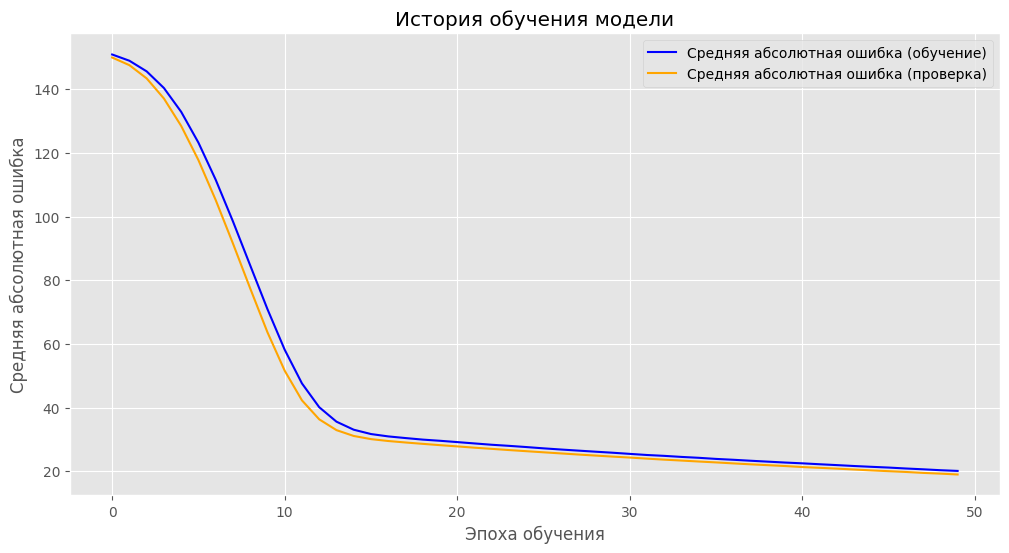

In [ ]:
model_simple = Sequential()
model_simple.add(BatchNormalization(input_dim=xTrain.shape[1]))
model_simple.add(Dense(128, activation='relu'))
model_simple.add(Dense(1000, activation='tanh'))
model_simple.add(Dense(100, activation='relu'))
model_simple.add(Dense(1, activation='linear'))

model_simple.compile(optimizer=Adam(learning_rate=1e-5), loss='mse', metrics=['mae'])

history = model_simple.fit(xTrain,
                    yTrain,
                    epochs=50,
                    batch_size=256,
                    validation_split=0.15,
                    verbose=1)

plot_history(history)

In [ ]:
# Функция оценки результатов и вывода оценки

def eval_net(model, x_train, y_train, y_scaler = None, n = 5, limit = 1000):
    plt.style.use('default')

    pred = model.predict(x_train)             # Предсказание на тренировочной выборке
    if y_scaler:                              # Если есть нормирование - то денормировать
        pred = y_scaler.inverse_transform(pred)
        print('денормирование y_train')

    print('Средняя абсолютная ошибка:', mean_absolute_error(pred, y_train), '\n')

    for i in range(n):
        print('Реальное значение: {:6.2f}  Предсказанное значение: {:6.2f}  Разница: {:6.2f}'.format(y_train[i, 0],
                                                                                                    pred[i, 0],
                                                                                                    abs(y_train[i, 0] - pred[i, 0])))
    # Построение картинки разброса предсказанных и верных значений зарплаты
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_train, pred)                 # Отрисовка точечного графика
    ax.set_xlim(0, limit)                     # Пределы по x, y
    ax.set_ylim(0, limit)
    ax.plot(plt.xlim(), plt.ylim(), 'r')      # Отрисовка диагональной линии
    plt.xlabel('Правильные значения')
    plt.ylabel('Предсказания')
    plt.grid()
    plt.show()

In [ ]:
input1 = Input((xTrain.shape[1],))
input2 = Input((xBOW_text.shape[1],))

x1 = input1                               # Ветка 1
x1 = Dense(128, activation="relu")(x1)
x1 = Dense(1000, activation="tanh")(x1)
x1 = Dense(100, activation="relu")(x1)

x2 = input2                               # Ветка 2
x2 = Dense(20, activation="relu")(x2)
x2 = Dense(500, activation="relu")(x2)
x2 = Dropout(0.3)(x2)

x = concatenate([x1, x2])             # Объединение трех веток

x = Dense(15, activation='relu')(x)       # Промежуточный слой
x = Dropout(0.5)(x)
x = Dense(1, activation='linear')(x)      # Финальный регрессирующий нейрон

# В Model передаются входы и выход
model_final = Model((input1, input2), x)

In [ ]:
model_final.compile(optimizer=Adam(learning_rate=1e-2), loss='mse', metrics=['mae'])

history = model_final.fit([xTrain, xBOW_text],
                           yTrain,
                           batch_size=256,
                           epochs=60,
                           validation_split=0.15,
                           verbose=1)

Epoch 1/60
175/175 [==============================] - 4s 11ms/step - loss: 4047.9429 - mae: 50.9336 - val_loss: 1032.0468 - val_mae: 24.9181
Epoch 2/60
175/175 [==============================] - 2s 10ms/step - loss: 3407.5144 - mae: 47.1159 - val_loss: 1315.1193 - val_mae: 29.9912
Epoch 3/60
175/175 [==============================] - 2s 9ms/step - loss: 3335.5830 - mae: 46.7010 - val_loss: 1200.3076 - val_mae: 28.1371
Epoch 4/60
175/175 [==============================] - 1s 7ms/step - loss: 3302.7434 - mae: 46.3209 - val_loss: 791.1411 - val_mae: 20.1611
Epoch 5/60
175/175 [==============================] - 1s 7ms/step - loss: 3169.2273 - mae: 45.4672 - val_loss: 1099.5807 - val_mae: 24.9382
Epoch 6/60
175/175 [==============================] - 1s 7ms/step - loss: 3121.5178 - mae: 45.0497 - val_loss: 1299.4170 - val_mae: 28.1814
Epoch 7/60
175/175 [==============================] - 1s 7ms/step - loss: 3081.2261 - mae: 44.8595 - val_loss: 954.6873 - val_mae: 21.8683
Epoch 8/60
175/175 [

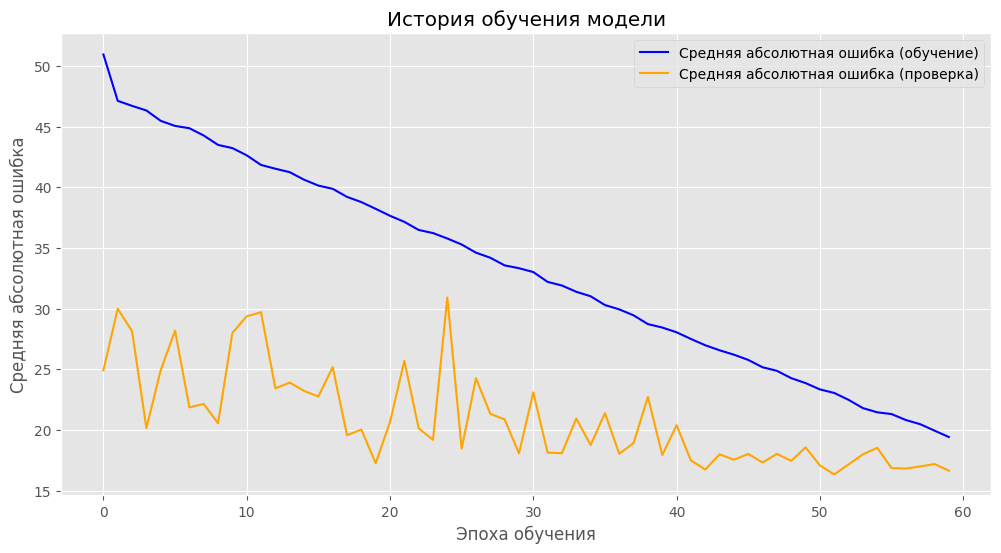

In [ ]:
plot_history(history)